# Day 3 — Baseline Models
Goal: establish the benchmark MAPE/RMSE that Day 5's spatial/GNN model must beat.


In [18]:
!pip install xgboost -q


In [19]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import json

df = pd.read_csv('kc_house_features.csv')
FEATURE_COLS = [c for c in df.columns if c not in ['id','price','zipcode']]
X = df[FEATURE_COLS]
y = df['price']

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)


(17148, 19) (4287, 19)


In [21]:
train_df = df.loc[idx_train].copy()
test_df = df.loc[idx_test].copy()

train_df.to_csv("data/train_split.csv", index=False)
test_df.to_csv("data/test_split.csv", index=False)

In [22]:
import sklearn
print(sklearn.__version__)

1.6.1


In [23]:
# --- Linear Regression baseline ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LinearRegression().fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)

lr_mape = mean_absolute_percentage_error(y_test, lr_pred) * 100
from sklearn.metrics import mean_squared_error
import numpy as np

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print(f"Linear Regression -> MAPE: {lr_mape:.2f}%  RMSE: ${lr_rmse:,.0f}  R2: {lr_r2:.3f}")


Linear Regression -> MAPE: 25.67%  RMSE: $186,074  R2: 0.723


In [24]:
# --- XGBoost baseline (the one Project 3's spec explicitly names) ---
xgb = XGBRegressor(
    n_estimators=600, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"XGBoost -> MAPE: {xgb_mape:.2f}%  RMSE: ${xgb_rmse:,.0f}  R2: {xgb_r2:.3f}")


XGBoost -> MAPE: 12.14%  RMSE: $107,864  R2: 0.907


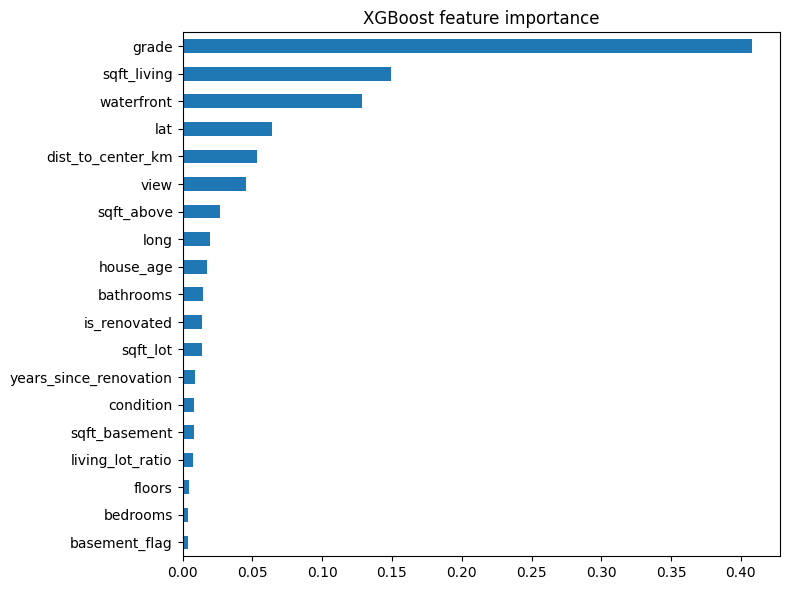

In [25]:
import matplotlib.pyplot as plt
importances = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title('XGBoost feature importance')
plt.tight_layout()
plt.savefig("reports/figures/xgboost_feature_importance.png", dpi=150)
plt.show()


In [26]:
baseline_metrics = {
    "dataset": "King County Housing",
    "train_size": len(X_train),
    "test_size": len(X_test),
    "random_state": 42,
    "linear_regression": {
        "MAPE": float(lr_mape),
        "RMSE": float(lr_rmse),
        "R2": float(lr_r2)
    },
    "xgboost": {
        "MAPE": float(xgb_mape),
        "RMSE": float(xgb_rmse),
        "R2": float(xgb_r2)
    }
}

with open("data/baseline_metrics.json","w") as f:
    json.dump(baseline_metrics, f, indent=4)

In [27]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "MAPE": [lr_mape, xgb_mape],
    "RMSE": [lr_rmse, xgb_rmse],
    "R2": [lr_r2, xgb_r2]
})

comparison

,Model,MAPE,RMSE,R2
0,Linear Regression,25.673606,186074.085356,0.723101
1,XGBoost,12.136701,107863.610642,0.906954


In [28]:
comparison.to_csv("data/baseline_model_comparison.csv", index=False)

In [29]:
import os

os.makedirs("models", exist_ok=True)

In [30]:
import joblib

joblib.dump(xgb, "models/xgboost_baseline.pkl")
joblib.dump(lr, "models/linear_regression.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

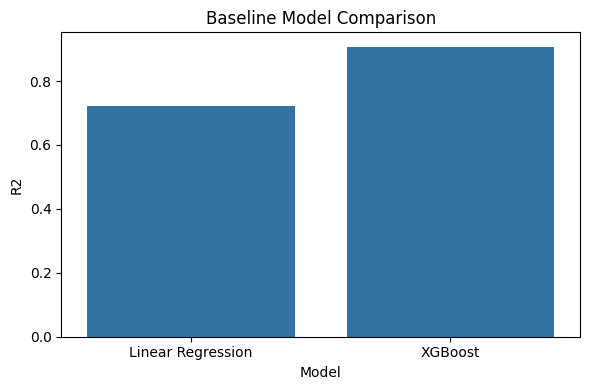

In [31]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="R2")
plt.title("Baseline Model Comparison")
plt.tight_layout()
plt.savefig("reports/figures/baseline_model_comparison.png", dpi=150)
plt.show()

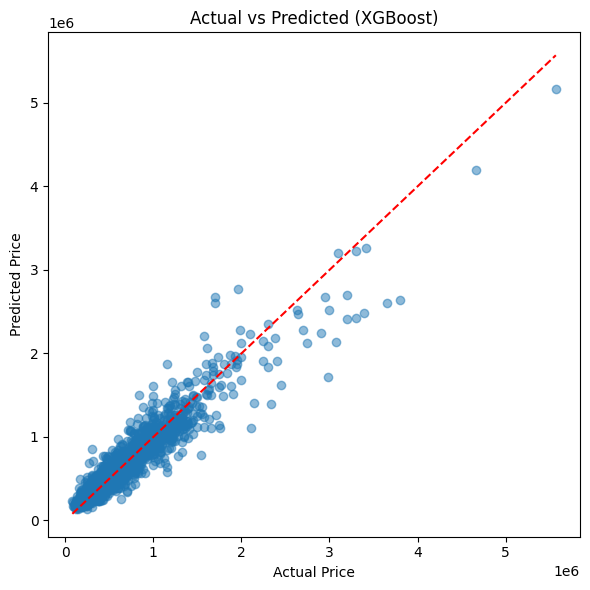

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    xgb_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (XGBoost)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.tight_layout()

plt.savefig("reports/figures/actual_vs_predicted.png", dpi=150)


plt.show()

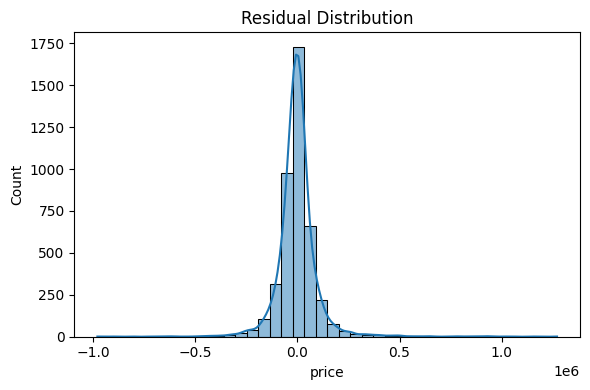

In [33]:
residuals = y_test - xgb_pred

plt.figure(figsize=(6,4))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig("reports/figures/residual_distribution.png", dpi=150)
plt.show()

In [34]:
os.makedirs("reports/figures", exist_ok=True)

In [35]:
os.makedirs("data", exist_ok=True)

## Day 3 Summary

- Built baseline regression models using Linear Regression and XGBoost.
- Compared models using RMSE, MAPE, and R².
- XGBoost achieved the best performance (R² = 0.907, MAPE = 12.14%).
- Saved trained models, evaluation metrics, and visualisations for future comparison.
- Next step: incorporate spatial information to improve prediction accuracy.